<a href="https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/Wavy_Channel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LEARNING OBJECTIVE

This notebook shows how to find the pressure drop along a rigid but wavy channel, given the inlet flow rate, using lubrication theory.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [74]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
import matplotlib.patches as patches
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy.integrate import quad

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

Problem formulation adapted from Panton's _Incompressible Flow_, 4th ed., prob. 22.1 (B).

# FLOW IN A WAVY CHANNEL

Find the pressure drop due to steady, low-Reynolds-number, pressure-driven flow in a wavy channel, $0<y<h(x)$, where $h(x) = h_0 + A \sin(2\pi x/L)$, using lubrication theory.

## Governing equations

The dimensional lubrication equations are
\begin{alignat*}{3}
    \text{[COM]}\qquad &&\frac{\partial v_x}{\partial x} + \frac{\partial v_y}{\partial y} &= 0,\\
    \text{[COLM-$x$]}\qquad &&0 &\approx -\frac{\partial p}{\partial x} + \mu \frac{\partial^2 v_x}{\partial y^2},\\
    \text{[COLM-$y$]}\qquad &&0 &\approx -\frac{\partial p}{\partial y}.
\end{alignat*}
The boundary conditions (no slip, no penetration, and given inlet/outlet pressure) are
\begin{align*}
    v_x(x,y=0) &= 0,\\
    v_y(x,y=0) &= 0.\\
    v_x\big(x,y=h(x)\big) &= 0,\\
    v_y\big(x,y=h(x)\big) &= 0,\\
    p(x=0,y) &= p_\mathrm{in},\\
    p(x=L,y) &= p_\mathrm{out}0.
\end{align*}

## The horizontal velocity

The solution of COLM-$y$ subject to these boundary conditions is easily shown to be Poiseuille flow, but with $h=h(x)$:
$$
    v_x(x,y) = \frac{[h(x)]^2}{2\mu}\left(-\frac{\partial p}{\partial x}\right) \left\{ \frac{y}{h(x)} - \left[\frac{y}{h(x)}\right]^2 \right\},
$$
where the pressure $p(x)$ is currently unknown. We'll keep using partial derivatives for clarity, but most quantities are only functions of $x$.

From the velocity, we can calculate the flow rate across any vertical cross-section:
$$
    Q = \int_0^{h(x)} v_x(x,y) \,dy =  - \frac{[h(x)]^3}{12\mu} \frac{\partial p}{\partial x} .
$$

## The pressure drop

Integrating COM from $y=0$ to $y=h(x)$ and using the boundary condition, we get
\begin{align*}
    \underbrace{v_y\big(x,y=h(x)\big)}_{=0} - \underbrace{v_y\big(x,y=0\big)}_{0} &= - \int_0^{h(x)} \frac{\partial v_x}{\partial x} \,dy \\
      &\overbrace{=}^{\text{Leibniz}} - \frac{\partial}{\partial x} \int_0^{h(x)} v_x(x,y) \,dy + \underbrace{v_x\big(x,y=h(x)\big)}_{0} \, \frac{\partial h}{\partial x} \\
      &= - \frac{\partial Q}{\partial x} ,
\end{align*}
from which, we learn that the flow rate is _constant everywhere_; the inlet $Q$ is maintained at **any** $x$ in the channel.

Thus, 
$$
    -\frac{[h(x)]^3}{12\mu}\frac{\partial p}{\partial x} = Q = const.,
$$
and we can separate and integrate from $x=0$ to $x=L$:
$$
    \underbrace{p(x=L) - p(x=0)}_{-\Delta p} = - 12 \mu Q \int_0^L \frac{1}{[h(x)]^3} dx.
$$
Hence,
\begin{align*}
   \frac{\Delta p}{L} &= \frac{12 \mu Q}{L} \int_0^L \frac{dx}{[h(x)]^3} \\
                      &= \frac{12 \mu Q}{h_0^3} \int_0^1 \frac{dx^*}{[h^*(x^*)]^3},
\end{align*}
where the dimensionless channel shape is 
$$
    h^*(x^*) = \frac{h(x)}{h_0} = 1 + \frac{A}{h_0} \sin(2\pi x^*).
$$

Note that the channel _cannot close_, thus we need to ensure that $A/h_0 < 1$.

# PRESSURE DROP FOR GIVEN CHANNEL SHAPE

Calculating $\Delta p$ boils down to evaluating an integral, since we've shown that
$$
    \frac{\Delta p/L}{12\mu Q/h_0^3} = \int_0^1 \frac{dx^*}{[h^*(x^*)]^{3}}.
$$

Set the shape.

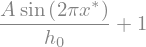

In [53]:
xs, A, h0, Aoverh0 = sp.symbols('x^*, A, h_0, (A/h_{0})')
# getting a little fancy with the priting of Aoverh0 ratio

hs = 1 + A/h0*sp.sin(2*sp.pi*xs)
hs

Plot the shape.

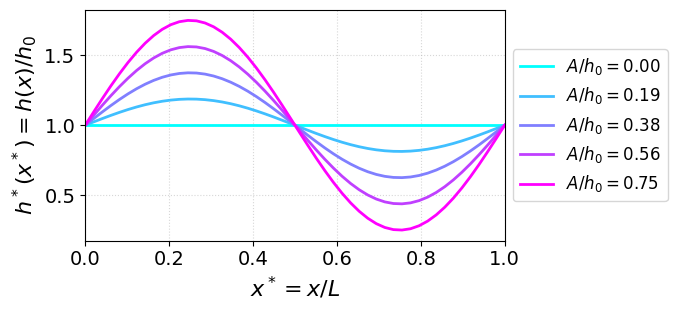

In [93]:
fig, ax = plt.subplots(tight_layout=True, figsize=(7,5))

# sequential colormap with gradient that looks nice
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['cool']

# A/h_0 from 0 to whatever you want
Aoh0 = np.linspace(0, 0.75, num=5)
# x^* goes from 0 to 1
xsp = np.linspace(0, 1)

# Loop over A/h0 values and plot h(x) for each
for i, tmp in enumerate(Aoh0):
    hsp = 0*xsp
    
    for j, x in enumerate(xsp):
        hsp[j] = hs.subs({xs: x, A: tmp, h0: 1})
    
    randcol = cmap(i/(len(Aoh0)-1)) # argument from 0 to 1
    ax.plot(xsp, hsp, label=f'$A/h_0 = {tmp:.2f}$', color=randcol, linewidth=2)

ax.set_xlabel('$x^* = x/L$')
ax.set_xlim(0,1)
ax.set_ylabel(r'$h^*(x^*) = h(x)/h_0$')

# show a grid to make it easier to see where the y=0 interface is
ax.grid(alpha=0.5, linestyle='dotted')

ax.set_aspect(1 / 3)

# move legend off the plot because it is too long
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

It may or may not be possible to evalaute the integral analytically for arbitrary $h^*(x^*)$, ...

In [5]:
#sp.integrate(1/hs**3, (xs, 0, 1))

But we can do it numerically. First, we [`lambdify`](https://docs.sympy.org/latest/modules/utilities/lambdify.html) our function for evaluation and plotting.

In [14]:
# lambda function for numerical evaluation
# without loss of generality set h0 = 1, then A is A/h0
hs_func = sp.lambdify((xs, Aoverh0), hs.subs(h0,1).subs(A,Aoverh0), 'numpy')

Since $h^*(x^*)$ is given analytically, we can use SciPy's [`quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html), instead of `trapezoid`, to get a highly accurate evaluation.

In [16]:
# this requires one more lambidification 
# to substitute the value of A/h0 = 0.5 in this example
quad(lambda x: 1/hs_func(x, 0.5)**3, 0, 1)

 The first number is the integral's value. The second number is the error estimate. Looks accurate!

## VISUALIZATION

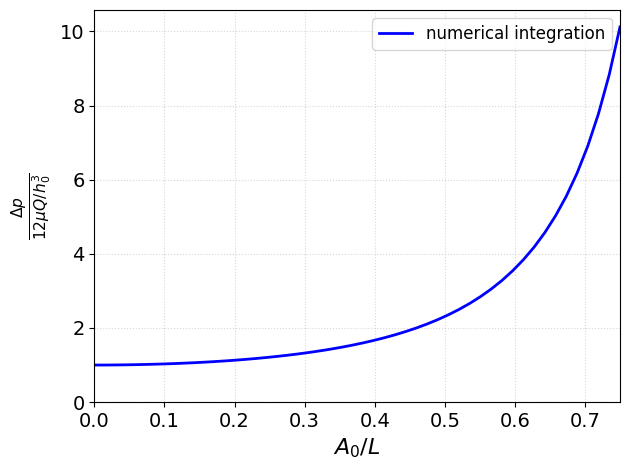

In [95]:
# A/h_0 from 0 to whatever you want
Aoh0 = np.linspace(0, 0.75)
dp = Aoh0*0  # placeholder for pressure drop values

# Evaluate pressure drop for each A/h0
for i, tmp in enumerate(Aoh0):
    dp[i] = quad(lambda x: 1/hs_func(x, tmp)**3, 0, 1)[0]

fig, ax = plt.subplots(tight_layout=True)

ax.plot(Aoh0, dp, linewidth=2, color='blue', label='numerical integration')

ax.set_ylabel(r'$\frac{\Delta p}{12\mu Q/h_0^3}$')
ax.set_ylim(bottom=0)
ax.set_xlabel('$A_0/L$')
ax.set_xlim(0,Aoh0.max())

# show a grid to make it easier to see where the y=0 interface is
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

plt.show()

# APPROXIMATE SOLUTION FOR $A/h_0\ll1$

We can make some progress if the wavyness is "small", specifically $A/h_0 \ll 1$. To this end, expand the integrand for small $A/h_0 \ll 1$:

In [54]:
integrand_series = sp.series(1/hs.subs(h0,1).subs(A,Aoverh0)**3, Aoverh0, 0, 3)
integrand_series

In [56]:
# removeO to get rid of the big O term and integrate the first few terms
dp_correction = sp.integrate(integrand_series.removeO(), (xs, 0, 1))
dp_correction

Thus, 
$$
    \frac{\Delta p}{L} \approx  \frac{12 \mu Q }{h_0^3} \left[ 1 + 3 \left(\frac{A}{h_0}\right)^2 + \cdots \right].
$$
We recognize the "$1$" in the brackets as the term due to Poiseuille flow in a channel of constant height $h_0$, and the "$3(A/h_0)^2$" as the correction due to the wavy nature of this channel.


## VISUALIZATION

Let's see how this approximation does compared to the numerical result.

In [59]:
dp_correction.subs(Aoverh0, 1)

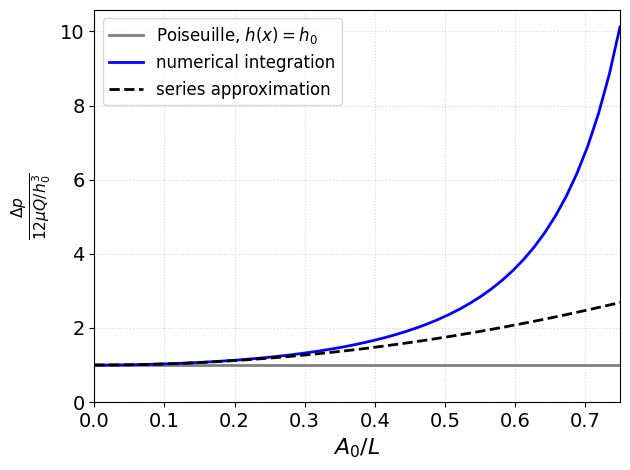

In [67]:
# A/h_0 from 0 to whatever you want
Aoh0 = np.linspace(0, 0.75)

# placeholders for pressure drop values
dp = Aoh0*0
dp_approx = Aoh0*0

# Evaluate pressure drop for each A/h0
for i, tmp in enumerate(Aoh0):
    dp[i] = quad(lambda x: 1/hs_func(x, tmp)**3, 0, 1)[0]
    dp_approx[i] = dp_correction.subs(Aoverh0, tmp)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(Aoh0, np.ones_like(Aoh0), linewidth=2, color='gray', label=r'Poiseuille, $h(x) = h_0$')
ax.plot(Aoh0, dp, linewidth=2, color='blue', label='numerical integration')
ax.plot(Aoh0, dp_approx, linewidth=2, linestyle='dashed', color='black', label='series approximation')

ax.set_ylabel(r'$\frac{\Delta p}{12\mu Q/h_0^3}$')
ax.set_ylim(bottom=0)
ax.set_xlabel('$A_0/L$')
ax.set_xlim(0,Aoh0.max())

ax.legend()

# show a grid to make it easier to see where the y=0 interface is
ax.grid(alpha=0.5, linestyle='dotted')

plt.show()

We learn that maintaining the same flow rate $Q$ in a wavy channel takes a _larger_ pressure drop than in a straight channel (Hagen&ndash;Poiseuille law). The pressure drop increase also shoots up dramatically as $A_0/L$ increases (that is, as the channel becomes more constricted somewhere).

# FURTHER EXPLORATION

On your own:

*   Try to keep more terms in the series approximation to get the next correction (and check its accuracy).
*   Make the wall "more wavy" by replacing $\sin(2\pi x/L)$ with $\sin(2\pi n x/L)$ for some integer $n>1$.